# 13. Análisis de la Cesta (Market Basket Analysis)

## 🎯 Objetivos
Al finalizar este notebook podrás:
- Explicar los conceptos de transacción, itemset, itemset frecuente y regla de asociación.
- Calcular soporte, confianza, lift, leverage y conviction.
- Generar itemsets frecuentes con Apriori.
- Extraer reglas de asociación con `mlxtend`.
- Filtrar y ordenar reglas según distintos criterios de negocio.
- Implementar un recomendador simple basado en reglas.
- Entender ventajas y limitaciones de Apriori y FP-Growth.

---
## 1. Introducción 💡
El análisis de la cesta busca descubrir relaciones de co-ocurrencia entre ítems comprados juntos en transacciones (e.g. supermercado, e-commerce, navegación web).

El análisis de la cesta se utiliza para descubrir patrones de compra conjunta entre productos en transacciones de clientes. Es muy común en supermercados, e-commerce y análisis de comportamiento de usuarios. Permite responder preguntas como:

- ¿Qué productos suelen comprarse juntos?
- ¿Qué reglas de asociación existen entre los ítems?
- ¿Cómo puedo recomendar productos relevantes a un cliente?

Esto ayuda a:

- Mejorar la disposición de productos en tiendas.
- Diseñar promociones y ventas cruzadas.
- Personalizar recomendaciones en plataformas online.

Ejemplo típico: 'Si un cliente compra pan y mantequilla, también compra mermelada'.

---
## 2. Definiciones Clave
| Concepto | Descripción |
|----------|-------------|
| Transacción | Conjunto de ítems adquiridos en una operación (por ejemplo una compra) |
| Itemset | Subconjunto de ítems (por ejemplo, {pan, leche}) |
| Itemset frecuente | Itemset cuyo soporte ≥ umbral min_support |
| Regla de asociación | A → B (A y B disjuntos) |

---
## 3. Métricas Principales 📏
Supongamos una regla A → B.
- Soporte (support): Proporción de transacciones que contienen un itemset. 
support(A) = frecuencia(A) / total de transacciones
- Confianza (confidence): Probabilidad de que B ocurra dado que A ocurre.
confidence(A→B) = support(A ∪ B) / support(A)
- Lift: Medida de la fuerza de la regla respecto a la independencia.
lift(A→B) = confidence(A→B) / support(B)
(Lift > 1 indica asociación positiva)
- Leverage: Diferencia entre el soporte conjunto y el esperado si fueran independientes.
leverage(A→B) = support(A ∪ B) - support(A)*support(B)
- Conviction: Medida de la dependencia de la regla.
conviction(A→B) = (1 - support(B)) / (1 - confidence(A→B))

---
## 4. Creación de Dataset Sintético de Transacciones 🧪

In [3]:
%pip install mlxtend

import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules

import warnings
warnings.filterwarnings('ignore')

random.seed(42)
np.random.seed(42)

items = ['pan','leche','mantequilla','mermelada','cafe','te','azucar','huevos','queso','cereal','yogur','manzana','platano','pollo','arroz']

# Generamos 1000 transacciones con sesgos de co-ocurrencia
transactions = []
for _ in range(1000):
    basket = set()
    # Base: cada cliente compra 2-6 ítems
    n_items = np.random.randint(2,7)
    # Probabilidades base (ponderamos algunos staples)
    probs = np.array([0.55,0.50,0.30,0.18,0.40,0.25,0.33,0.28,0.22,0.27,0.31,0.45,0.43,0.20,0.35])
    chosen = np.random.choice(items, size=n_items, replace=False, p=probs/probs.sum())
    basket.update(chosen)
    # Reglas sintéticas (inyectamos correlaciones)
    if 'pan' in basket and random.random()<0.35: basket.add('mantequilla')
    if 'pan' in basket and 'mantequilla' in basket and random.random()<0.25: basket.add('mermelada')
    if 'cafe' in basket and random.random()<0.30: basket.add('azucar')
    if 'cereal' in basket and random.random()<0.50: basket.add('leche')
    if 'yogur' in basket and random.random()<0.40: basket.add('manzana')
    if 'arroz' in basket and random.random()<0.35: basket.add('pollo')
    transactions.append(sorted(basket))

print('Ejemplo de transacciones (primeras 5):')
for t in transactions[:5]:
    print(t)
print('Total transacciones:', len(transactions))

Note: you may need to restart the kernel to use updated packages.
Ejemplo de transacciones (primeras 5):
[np.str_('arroz'), np.str_('leche'), np.str_('manzana'), np.str_('pan'), 'pollo', np.str_('queso')]
[np.str_('arroz'), np.str_('cereal'), np.str_('mantequilla'), 'mermelada', np.str_('pan'), np.str_('platano'), np.str_('yogur')]
[np.str_('huevos'), np.str_('leche'), 'manzana', np.str_('mermelada'), np.str_('te'), np.str_('yogur')]
[np.str_('arroz'), np.str_('mantequilla'), 'mermelada', np.str_('pan'), 'pollo']
[np.str_('arroz'), np.str_('azucar'), np.str_('cafe'), np.str_('platano'), 'pollo']
Total transacciones: 1000


---
## 5. Transformación a Formato One-Hot (Matriz de Incidencia)

In [4]:
# Construir DataFrame one-hot
# Estrategia: cada fila = transacción; columna = item; 1 si presente
from collections import Counter

encoded_rows = []
for basket in transactions:
    row = {item:0 for item in items}
    for it in basket: row[it]=1
    encoded_rows.append(row)

X = pd.DataFrame(encoded_rows)
X.head()

,pan,leche,mantequilla,mermelada,cafe,te,azucar,huevos,queso,cereal,yogur,manzana,platano,pollo,arroz
0,1,1,0,0,0,0,0,0,1,0,0,1,0,1,1
1,1,0,1,1,0,0,0,0,0,1,1,0,1,0,1
2,0,1,0,1,0,1,0,1,0,0,1,1,0,0,0
3,1,0,1,1,0,0,0,0,0,0,0,0,0,1,1
4,0,0,0,0,1,0,1,0,0,0,0,0,1,1,1


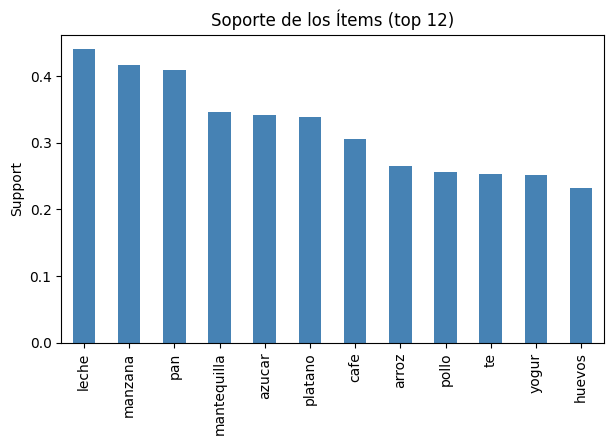

In [5]:
# Soporte individual aproximado
item_support = X.mean().sort_values(ascending=False)
plt.figure(figsize=(7,4))
item_support.head(12).plot(kind='bar', color='steelblue')
plt.ylabel('Support')
plt.title('Soporte de los Ítems (top 12)')
plt.show()

---
## 6. Generación de Itemsets Frecuentes (Apriori) 🔍
Elegimos un `min_support` inicial (ej: 0.05).

In [6]:
frequent_items = apriori(X, min_support=0.05, use_colnames=True)
frequent_items['length'] = frequent_items['itemsets'].apply(len)
frequent_items.sort_values(['length','support'], ascending=[True,False]).head(10)

,support,itemsets,length
1,0.440,(leche),1
11,0.416,(manzana),1
0,0.409,(pan),1
2,0.346,(mantequilla),1
6,0.341,(azucar),1
12,0.339,(platano),1
4,0.305,(cafe),1
14,0.265,(arroz),1
13,0.256,(pollo),1
5,0.253,(te),1


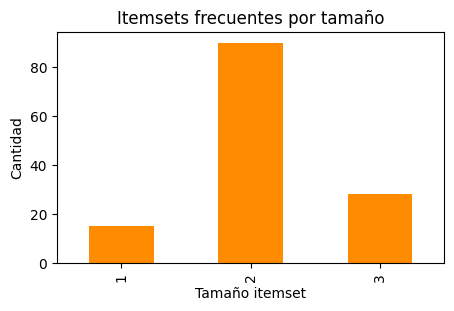

In [7]:
# Distribución por tamaño de itemset
counts_len = frequent_items['length'].value_counts().sort_index()
plt.figure(figsize=(5,3))
counts_len.plot(kind='bar', color='darkorange')
plt.xlabel('Tamaño itemset')
plt.ylabel('Cantidad')
plt.title('Itemsets frecuentes por tamaño')
plt.show()

---
## 7. Reglas de Asociación 📐
Extraemos reglas a partir de itemsets frecuentes y filtramos por confianza mínima.

In [8]:
rules = association_rules(frequent_items, metric='confidence', min_threshold=0.3)
# Ordenar por lift descendente
rules_sorted = rules.sort_values('lift', ascending=False)
rules_sorted[['antecedents','consequents','support','confidence','lift','leverage','conviction']].head(10)

,antecedents,consequents,support,confidence,lift,leverage,conviction
162,"(manzana, pollo)",(arroz),0.053,0.519608,1.960784,0.025970,1.530000
98,"(mermelada, pan)",(mantequilla),0.068,0.647619,1.871731,0.031670,1.855946
99,"(mermelada, mantequilla)",(pan),0.068,0.764045,1.868081,0.031599,2.504714
160,"(arroz, manzana)",(pollo),0.053,0.452991,1.769498,0.023048,1.360125
149,"(cereal, platano)",(leche),0.052,0.764706,1.737968,0.022080,2.380000
101,(mermelada),"(pan, mantequilla)",0.068,0.354167,1.736111,0.028832,1.232516
100,"(pan, mantequilla)",(mermelada),0.068,0.333333,1.736111,0.028832,1.212000
131,"(leche, mantequilla)",(cereal),0.057,0.385135,1.696631,0.023404,1.257187
85,(pollo),(arroz),0.111,0.433594,1.636203,0.043160,1.297655
84,(arroz),(pollo),0.111,0.418868,1.636203,0.043160,1.280260


Podemos aplicar filtros de negocio. Ej.: soporte ≥ 0.05, confianza ≥ 0.4, lift ≥ 1.2.

In [9]:
filtered = rules[(rules['support']>=0.05) & (rules['confidence']>=0.4) & (rules['lift']>=1.2)]
filtered = filtered.sort_values('lift', ascending=False)
filtered[['antecedents','consequents','support','confidence','lift']].head(15)

,antecedents,consequents,support,confidence,lift
162,"(manzana, pollo)",(arroz),0.053,0.519608,1.960784
98,"(mermelada, pan)",(mantequilla),0.068,0.647619,1.871731
99,"(mermelada, mantequilla)",(pan),0.068,0.764045,1.868081
160,"(arroz, manzana)",(pollo),0.053,0.452991,1.769498
149,"(cereal, platano)",(leche),0.052,0.764706,1.737968
84,(arroz),(pollo),0.111,0.418868,1.636203
85,(pollo),(arroz),0.111,0.433594,1.636203
29,(cereal),(leche),0.159,0.700441,1.591910
132,"(cereal, mantequilla)",(leche),0.057,0.695122,1.579823
146,"(cereal, manzana)",(leche),0.061,0.685393,1.557712


---
## 8. Cálculo Manual de Métricas (Verificación) ✍️
Tomamos la primera regla filtrada y verificamos soporte y confianza manualmente.

In [11]:
if not filtered.empty:
    r = filtered.iloc[0]
    A = set(r['antecedents'])
    B = set(r['consequents'])
    both = A.union(B)
    # Cálculo manual
    sup_A = (X[list(A)].all(axis=1)).mean()
    sup_B = (X[list(B)].all(axis=1)).mean()
    sup_both = (X[list(both)].all(axis=1)).mean()
    conf_manual = sup_both / sup_A
    lift_manual = conf_manual / sup_B
    print('Regla:', A, '->', B)
    print(f'Soporte A: {sup_A:.3f}, Soporte B: {sup_B:.3f}, Soporte A∪B: {sup_both:.3f}')
    print(f'Confianza (manual): {conf_manual:.3f}, Confianza (sklearn): {r["confidence"]:.3f}')
    print(f'Lift (manual): {lift_manual:.3f}, Lift (sklearn): {r["lift"]:.3f}')
else:
    print('No hay reglas que cumplan los criterios de filtrado.')   

Regla: {'manzana', 'pollo'} -> {'arroz'}
Soporte A: 0.102, Soporte B: 0.265, Soporte A∪B: 0.053
Confianza (manual): 0.520, Confianza (sklearn): 0.520
Lift (manual): 1.961, Lift (sklearn): 1.961
